In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'SimHei'

In [4]:
i = 0
dp = "C:/Users/wangsx/Desktop/20260514_YAK_Data/"
files = os.listdir(dp)
fp = os.path.join(dp, files[i])
df = pd.read_csv(fp)

In [5]:
df

,record_time,sub_index,rri,area_up,area_down,motion
0,2025-03-12 09:04:25,0,750,7,212,938
1,2025-03-12 09:04:25,1,610,5,210,375
2,2025-03-12 09:04:26,0,760,3,208,57
3,2025-03-12 09:04:27,0,870,1,206,40
4,2025-03-12 09:04:28,0,900,0,204,7
...,...,...,...,...,...,...
104059,2025-03-13 08:29:47,1,790,405,583,4
104060,2025-03-13 08:29:48,0,690,405,583,5
104061,2025-03-13 08:29:49,0,660,405,583,7
104062,2025-03-13 08:29:50,0,660,405,583,3


In [13]:
time = pd.to_datetime(df.record_time, format="%Y-%m-%d %H:%M:%S").astype('datetime64[s]').astype('int64')
time

0         1741770265
1         1741770265
2         1741770266
3         1741770267
4         1741770268
             ...    
104059    1741854587
104060    1741854588
104061    1741854589
104062    1741854590
104063    1741854590
Name: record_time, Length: 104064, dtype: int64

In [15]:
dt = time.diff()

In [16]:
gap = np.where(dt > 1)[0]

In [17]:
gap

array([14592, 19776, 34080, 36288, 46368, 48672, 50880, 99931, 99991])

In [18]:
dt[gap]

14592     68.0
19776     71.0
34080     73.0
36288     85.0
46368     70.0
48672     78.0
50880     78.0
99931    112.0
99991     83.0
Name: record_time, dtype: float64

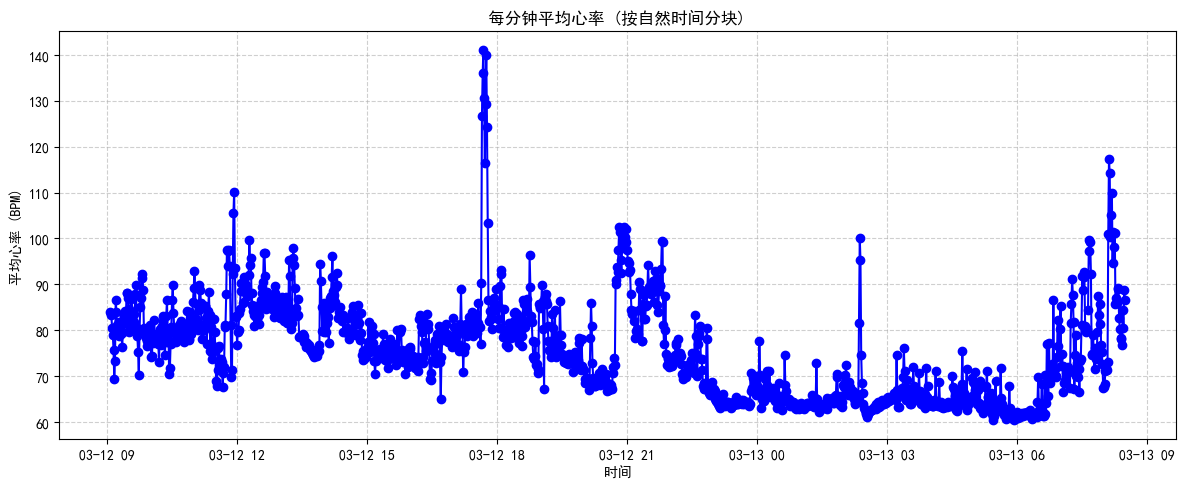

In [23]:
df['hr'] = 6e4 / df.rri
df['datetime'] = pd.to_datetime(df.record_time, format="%Y-%m-%d %H:%M:%S").astype('datetime64[s]')
hr_per_min = df.set_index('datetime')['hr'].resample('1min').mean()
# 3. 可视化
plt.figure(figsize=(12, 5))
# 用点和线连接，直观展示每分钟的均值
plt.plot(hr_per_min.index, hr_per_min.values, marker='o', linestyle='-', color='b')

plt.title("每分钟平均心率 (按自然时间分块)")
plt.xlabel("时间")
plt.ylabel("平均心率 (BPM)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

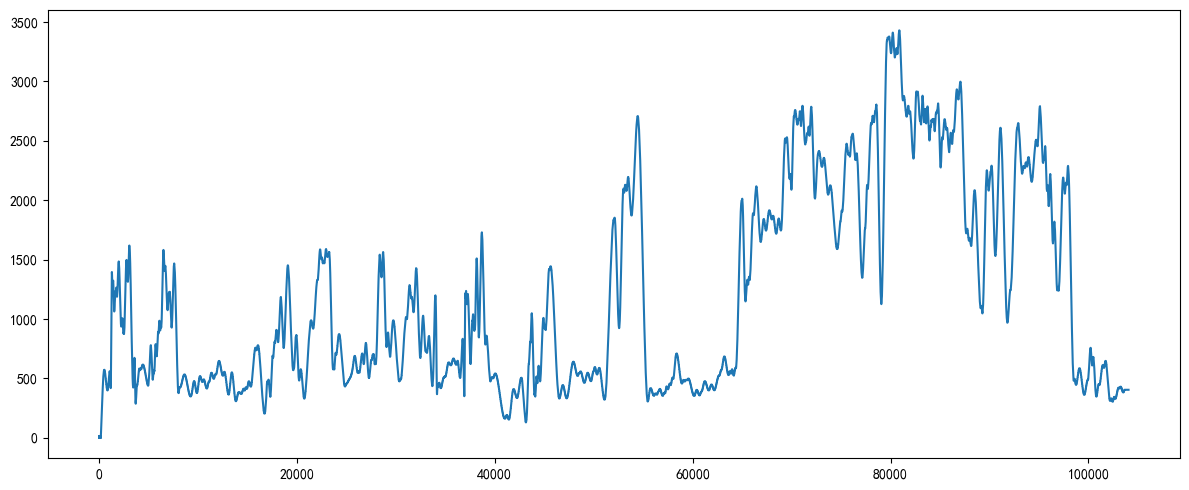

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(df.area_up.to_numpy())
plt.tight_layout()
plt.show()